# Titanic Survival — Part 1b: Modeling & Evaluation

This notebook continues from [`titanic_survival_part_1a.ipynb`](titanic_survival_part_1a.ipynb), which produced `data/titanic_clean.csv`. Here we:

1. **Load** the cleaned dataset.
2. **Split** into train and test sets and **standardize** the features.
3. **Train** a logistic-regression classifier with scikit-learn.
4. **Evaluate** the model with several complementary metrics and visualizations.

If `data/titanic_clean.csv` does not exist yet, run the exploration notebook first.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CLEAN_PATH = "../data/titanic_clean.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_ITER = 1000

## 1. Load the cleaned dataset

We load the CSV produced by Part 1a. The exploration notebook already removed duplicates, typecast `age` to int, dropped redundant columns, and added `family_size_lt4`.

In [2]:
clean = pd.read_csv(CLEAN_PATH)

print(f"Shape: {clean.shape}")
print(f"Columns: {list(clean.columns)}")
clean.head()

Shape: (817, 6)
Columns: ['sex', 'age', '1st_class', '2nd_class', 'survived', 'family_size_lt4']


,sex,age,1st_class,2nd_class,survived,family_size_lt4
0,1,22,0,0,0,1
1,0,38,1,0,1,1
2,0,26,0,0,1,1
3,0,35,1,0,1,1
4,1,35,0,0,0,1


In [3]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 817 entries, 0 to 816
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   sex              817 non-null    int64
 1   age              817 non-null    int64
 2   1st_class        817 non-null    int64
 3   2nd_class        817 non-null    int64
 4   survived         817 non-null    int64
 5   family_size_lt4  817 non-null    int64
dtypes: int64(6)
memory usage: 38.4 KB


## 2. Train/test split and feature scaling

We split the data **before** scaling so the test set never influences the scaler — fitting the scaler on the full dataset would leak test-set statistics into training. The split is stratified on the target so train and test have the same survival rate.

`StandardScaler` puts every feature on roughly the same scale (mean 0, std 1), which also makes the learned coefficients comparable in magnitude.

In [4]:
TARGET = "survived"
FEATURES = [c for c in clean.columns if c != TARGET]

X = clean[FEATURES]
y = clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Total: {clean.shape[0]}, Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train survival rate: {y_train.mean():.2%}")
print(f"Test  survival rate: {y_test.mean():.2%}")

Total: 817, Train: 653, Test: 164
Train survival rate: 40.43%
Test  survival rate: 40.24%


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pd.DataFrame(X_train_s, columns=FEATURES).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sex,653.0,-0.0,1.0,-1.28,-1.28,0.78,0.78,0.78
age,653.0,-0.0,1.0,-2.01,-0.64,-0.09,0.59,3.47
1st_class,653.0,-0.0,1.0,-0.59,-0.59,-0.59,1.69,1.69
2nd_class,653.0,-0.0,1.0,-0.51,-0.51,-0.51,-0.51,1.95
family_size_lt4,653.0,0.0,1.0,-3.51,0.28,0.28,0.28,0.28


## 3. Model training

We fit scikit-learn's `LogisticRegression`. `max_iter=1000` is set generously to make sure the solver converges on this small dataset.

Because the features are standardized, the absolute size of each coefficient tells us how strongly that feature pushes the predicted probability up or down — a useful sanity check that the model has learned the patterns we saw during exploration.

In [6]:
model = LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE)
model.fit(X_train_s, y_train)

print("Learned coefficients (on standardized features):")
for name, coef in zip(FEATURES, model.coef_[0]):
    print(f"  {name:>16s}: {coef:+.4f}")
print(f"  {'bias':>16s}: {model.intercept_[0]:+.4f}")

Learned coefficients (on standardized features):
               sex: -1.2297
               age: -0.6083
         1st_class: +0.9646
         2nd_class: +0.4698
   family_size_lt4: +0.5191
              bias: -0.5335


**Reading the coefficients.** A negative `sex` coefficient (recall `sex=1` means male) means males are predicted to survive at a lower rate. Positive coefficients on `1st_class` and `2nd_class` confirm that travelling in a higher class — relative to the dropped 3rd-class reference — increases the predicted probability of survival. These match the patterns from the exploration plots.

## 4. Evaluation

A single accuracy number does not tell the whole story for a classifier — especially with mildly imbalanced classes (~40% survived). We therefore look at several complementary metrics:

- **Accuracy** — overall fraction of correct predictions.
- **Precision** — of the passengers we *predicted* to survive, how many actually did.
- **Recall** — of the passengers who *actually* survived, how many we caught.
- **F1** — harmonic mean of precision and recall, useful as a single number when comparing models.
- **ROC AUC** — how well the model ranks survivors above non-survivors, independent of the 0.5 decision threshold.
- **Confusion matrix** — the raw counts behind precision / recall.

In [7]:
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

In [8]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
for name, value in metrics.items():
    print(f"  {name:>10s}: {value:.3f}")

    accuracy: 0.854
   precision: 0.904
      recall: 0.712
          f1: 0.797
     roc_auc: 0.878


In [9]:
print(classification_report(y_test, y_pred, target_names=["died", "survived"]))

              precision    recall  f1-score   support

        died       0.83      0.95      0.89        98
    survived       0.90      0.71      0.80        66

    accuracy                           0.85       164
   macro avg       0.87      0.83      0.84       164
weighted avg       0.86      0.85      0.85       164



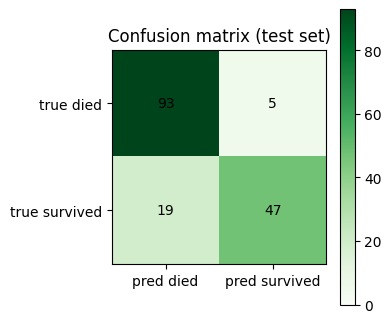

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Greens", vmin=0, vmax=cm.max())

ax.grid(False)
ax.set_title("Confusion matrix (test set)")
ax.set_xticks([0, 1], ["pred died", "pred survived"])
ax.set_yticks([0, 1], ["true died", "true survived"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

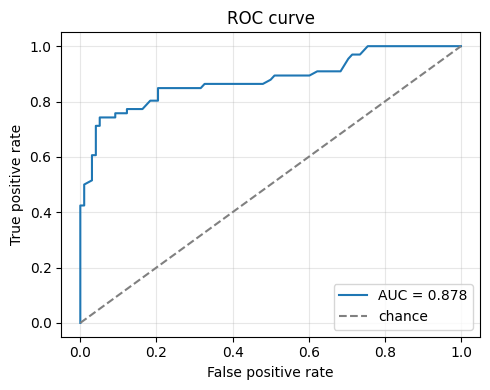

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4))

ax.set(
    title="ROC curve",
    xlabel="False positive rate",
    ylabel="True positive rate",
)

ax.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", label="chance")
ax.legend()

plt.tight_layout()
plt.show()

**What each metric reveals**

- **Accuracy** is solid but partly inflated by the majority class — predicting that *everyone died* would already give around 60% accuracy on this dataset, so accuracy alone overstates how good the model is.
- **Precision is higher than recall**: when the model predicts "survived" it is usually right, but it misses a meaningful share of actual survivors. The model is conservative about predicting survival — consistent with the imbalanced base rate.
- **F1** condenses precision and recall into one number; useful when comparing model variants.
- **ROC AUC** shows that the model ranks survivors above non-survivors much better than chance. Because AUC is computed from the *probabilities* it is independent of the 0.5 threshold, so it gives the most threshold-agnostic view of model quality. If we cared more about catching survivors than about avoiding false alarms, we could lower the decision threshold to trade some precision for recall without retraining.
- **The confusion matrix** makes the trade-off concrete: most errors are false negatives (real survivors classified as dead), which is what we expect given the precision/recall gap.

Together these metrics tell us the model has learned real signal — clearly above chance — but it is far from a perfect classifier. That is consistent with the modest set of features available and the inherent noise in survival on the Titanic.